# Clasificador de Lenguaje de Señas — Sign Language MNIST
## Regresión Logística Multiclase (One-vs-Rest)

---

**Universidad:** Universidad San Francisco Xavier de Chuquisaca (USFX)  
**Materia:** Inteligencia Artificial  
**Dataset:** [Sign Language MNIST — Kaggle](https://www.kaggle.com/datasets/datamunge/sign-language-mnist/data)

---

### Contexto del Problema

El Sign Language MNIST es un dataset de imágenes en escala de grises de **28×28 píxeles** que representan letras del alfabeto del **Lenguaje de Señas Americano (ASL)**. Cada imagen está aplanada en un vector de **784 características numéricas** (píxeles), lo que lo convierte en un dataset **multimodal**: aunque los datos son numéricos, su semántica es visual.

El dataset contiene **24 clases** (letras A–Y), omitiendo deliberadamente la **J** y la **Z** porque sus señas requieren movimiento — algo que una fotografía fija no puede capturar.

Nuestro objetivo es entrenar un modelo de **Regresión Logística Multiclase** capaz de identificar qué letra está siendo señalada en una imagen.

## 0. Instalación y Configuración de Dependencias

Verificamos que todas las librerías necesarias estén disponibles en el entorno.

In [1]:
# ─── Instalación de dependencias (si se ejecuta en Google Colab) ───
import subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn']
for pkg in required:
    try:
        __import__(pkg if pkg != 'scikit-learn' else 'sklearn')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Todas las dependencias están disponibles.')

✅ Todas las dependencias están disponibles.


In [2]:
# ─── Importaciones principales ───
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

# Configuración global de estilo
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
np.random.seed(42)

print('✅ Importaciones completadas.')

✅ Importaciones completadas.


---
## 1. Carga de Datos

Cargamos el archivo de entrenamiento proporcionado. A partir de él, generaremos la partición **80% entrenamiento / 20% prueba** de forma estratificada, garantizando que cada clase esté representada proporcionalmente en ambos subconjuntos.

In [4]:
# ─── Carga del dataset ───
# Si usas Google Colab, sube el archivo y ajusta la ruta:
# from google.colab import files
# uploaded = files.upload()  # selecciona sign_mnist_train.csv

CSV_PATH = '/content/sign_mnist_train.csv'   # ← ajusta si el archivo está en otra ruta

df_full = pd.read_csv(CSV_PATH)

print('─' * 50)
print(f'  Filas totales    : {df_full.shape[0]:,}')
print(f'  Columnas totales : {df_full.shape[1]}')
print(f'  Características  : {df_full.shape[1] - 1}  (n = 784 píxeles)')
print(f'  Clases únicas    : {df_full["label"].nunique()}')
print('─' * 50)
df_full.head(3)

──────────────────────────────────────────────────
  Filas totales    : 344
  Columnas totales : 785
  Características  : 784  (n = 784 píxeles)
  Clases únicas    : 24
──────────────────────────────────────────────────


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207.0,207.0,207.0,207.0,206.0,206.0,206.0,204.0,203.0,202.0
1,6,155,157,156,156,156,157,156,158,158,...,69.0,149.0,128.0,87.0,94.0,163.0,175.0,103.0,135.0,149.0
2,2,187,188,188,187,187,186,187,188,187,...,202.0,201.0,200.0,199.0,198.0,199.0,198.0,195.0,194.0,195.0


In [5]:
# ─── Distribución de clases ───
class_counts = df_full['label'].value_counts().sort_index()
print('Distribución de etiquetas (antes del split):')
print(class_counts.to_string())

Distribución de etiquetas (antes del split):
label
0     16
1     14
2     16
3     16
4     11
5      9
6     13
7      8
8      8
10    20
11    15
12     7
13    14
14    18
15    14
16    21
17     9
18    22
19    21
20    20
21    15
22    14
23    13
24    10


---
## 2. Mapeo de Etiquetas

El dataset utiliza etiquetas numéricas del **0 al 24**, que corresponden a las letras **A–Y** del alfabeto inglés, **omitiendo J (9) y Z (25)**. El índice 9 no existe en los datos; el salto va directamente de la I (8) a la K (10).

Este diccionario de mapeo es **crítico** para que las visualizaciones muestren la letra correcta en cada predicción.

In [6]:
# ─── Diccionario de mapeo: índice numérico → letra ───
# J (9) y Z (25) están excluidas porque requieren movimiento.
LABEL_MAP = {
    0:  'A', 1:  'B', 2:  'C', 3:  'D', 4:  'E',
    5:  'F', 6:  'G', 7:  'H', 8:  'I',
    # 9 → J  ← NO EXISTE en el dataset
    10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O',
    15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T',
    20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y'
}

CLASES_ORDENADAS = sorted(LABEL_MAP.keys())          # [0,1,2,...,8,10,...,24]
LETRAS_ORDENADAS = [LABEL_MAP[k] for k in CLASES_ORDENADAS]

print('Mapeo de etiquetas:')
print(LABEL_MAP)
print(f'\nTotal de clases: {len(LABEL_MAP)}')

Mapeo de etiquetas:
{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 10: 'K', 11: 'L', 12: 'M', 13: 'N', 14: 'O', 15: 'P', 16: 'Q', 17: 'R', 18: 'S', 19: 'T', 20: 'U', 21: 'V', 22: 'W', 23: 'X', 24: 'Y'}

Total de clases: 24


---
## 3. Visualización y Reconstrucción de Imágenes

Antes de cualquier preprocesamiento, es fundamental **visualizar los datos crudos** para desarrollar intuición sobre el problema. Cada fila del dataset es un vector de 784 valores de píxel (0–255), que debemos reorganizar en una matriz de **28×28** para recuperar la imagen original.

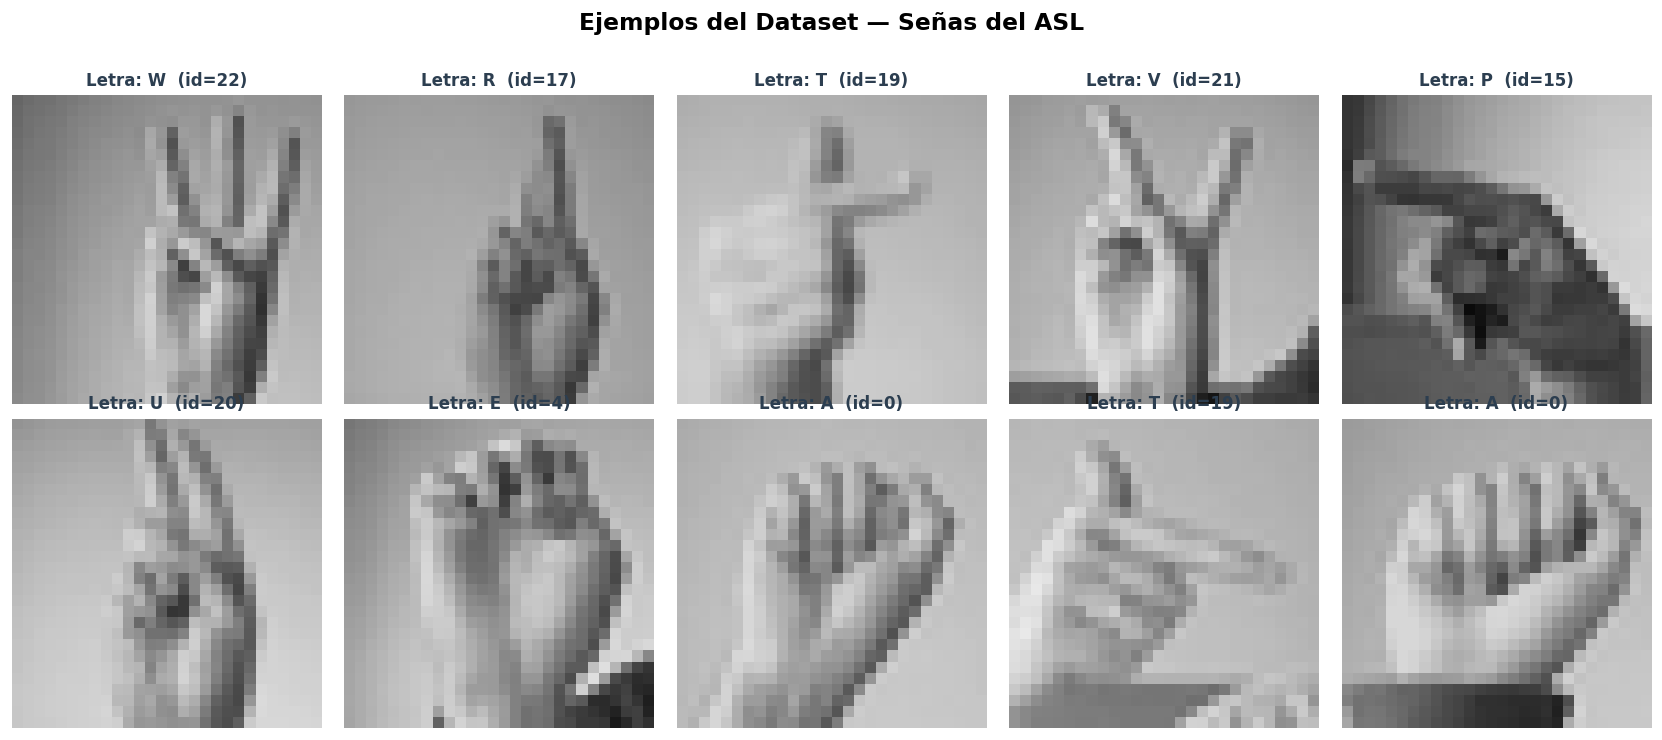

📸  Se muestran 10 ejemplos aleatorios del set de entrenamiento.


In [11]:
def visualizar_senas(df, n=10, titulo='Ejemplos del Dataset — Señas del ASL', seed=42):
    """
    Selecciona n ejemplos aleatorios del DataFrame, reconstruye cada imagen
    de 784 píxeles a una matriz 28×28 y las muestra en una cuadrícula.

    Parámetros
    ----------
    df    : DataFrame con columna 'label' y 784 columnas de píxeles.
    n     : Número de imágenes a mostrar.
    titulo: Título del plot.
    seed  : Semilla para reproducibilidad.
    """
    np.random.seed(seed)
    indices = np.random.choice(len(df), n, replace=False)
    muestra = df.iloc[indices]

    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle(titulo, fontsize=14, fontweight='bold', y=1.02)

    for ax, (_, fila) in zip(axes.ravel(), muestra.iterrows()):
        etiqueta_num = int(fila['label'])
        letra        = LABEL_MAP[etiqueta_num]
        imagen       = fila.drop('label').values.reshape(28, 28).astype(np.uint8)

        ax.imshow(imagen, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'Letra: {letra}  (id={etiqueta_num})',
                     fontsize=10, fontweight='bold', color='#2c3e50')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('senas_ejemplos.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'📸  Se muestran {n} ejemplos aleatorios del set de entrenamiento.')


visualizar_senas(df_full)

---
## 4. Preprocesamiento Técnico

### 4.1 Separación de características y etiquetas

In [12]:
# ─── X: píxeles · y: etiquetas ───
X_raw = df_full.drop(columns=['label']).values   # shape: (27455, 784)
y_raw = df_full['label'].values                  # shape: (27455,)

print(f'X (características): {X_raw.shape}  →  m={X_raw.shape[0]:,} muestras, n={X_raw.shape[1]} píxeles')
print(f'y (etiquetas)      : {y_raw.shape}')

X (características): (344, 784)  →  m=344 muestras, n=784 píxeles
y (etiquetas)      : (344,)


### 4.2 Normalización por Escala de Píxeles (÷ 255)

La **normalización es un paso imprescindible** en Regresión Logística cuando las características tienen rangos distintos o muy amplios. En este dataset, los valores de píxel van de **0 a 255**, lo cual genera dos problemas si no se normalizan:

1. **Convergencia lenta o nula:** El descenso del gradiente avanza a distintas velocidades en cada dimensión, creando superficies de costo elongadas que dificultan encontrar el mínimo.
2. **Regularización desequilibrada:** El término de regularización L2 penaliza desproporcionadamente las características con mayor magnitud numérica, sesgando los pesos aprendidos.

Al dividir entre 255, llevamos todos los píxeles al rango **[0, 1]**, lo que homogeneiza la escala y permite que el optimizador converja de forma eficiente.

In [13]:
# ─── Normalización: escala [0, 255] → [0.0, 1.0] ───
X_norm = X_raw / 255.0

print(f'Rango ANTES de normalizar  → min: {X_raw.min()}, max: {X_raw.max()}')
print(f'Rango DESPUÉS de normalizar → min: {X_norm.min():.4f}, max: {X_norm.max():.4f}')

Rango ANTES de normalizar  → min: nan, max: nan
Rango DESPUÉS de normalizar → min: nan, max: nan


### 4.3 Partición Estratificada 80 / 20

In [14]:
# ─── Split estratificado: 80% entrenamiento, 20% prueba ───
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_raw,
    test_size=0.20,
    stratify=y_raw,     # mantiene la proporción de clases
    random_state=42
)

print('─' * 45)
print(f'  X_train : {X_train.shape}   (80%)')
print(f'  X_test  : {X_test.shape}    (20%)')
print(f'  y_train : {y_train.shape}')
print(f'  y_test  : {y_test.shape}')
print('─' * 45)

─────────────────────────────────────────────
  X_train : (275, 784)   (80%)
  X_test  : (69, 784)    (20%)
  y_train : (275,)
  y_test  : (69,)
─────────────────────────────────────────────


---
## 5. Entrenamiento del Modelo — Regresión Logística Multiclase (OvR)

Utilizamos la estrategia **One-vs-Rest (OvR)**: por cada una de las 24 clases se entrena un clasificador binario independiente que aprende a distinguir esa letra de todas las demás. Al predecir, se elige la clase cuyo clasificador asignó la probabilidad más alta.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `multi_class` | `'ovr'` | Estrategia One-vs-Rest |
| `solver` | `'saga'` | Eficiente para datasets grandes y regularización L1/L2 |
| `C` | `0.1` | Regularización moderada para evitar sobreajuste en 784 features |
| `max_iter` | `1000` | Suficiente para garantizar convergencia |
| `n_jobs` | `-1` | Usa todos los núcleos de CPU disponibles |

In [15]:
# ─── Entrenamiento ───
print('⏳ Entrenando modelo de Regresión Logística...')
print('   (Esto puede tardar 1–3 minutos dependiendo del hardware)\n')

modelo = LogisticRegression(
    multi_class='ovr',
    solver='saga',
    C=0.1,
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

modelo.fit(X_train, y_train)

print('✅ Modelo entrenado exitosamente.')
print(f'   Iteraciones realizadas : {modelo.n_iter_.max()}')
print(f'   Clases detectadas      : {len(modelo.classes_)}')

⏳ Entrenando modelo de Regresión Logística...
   (Esto puede tardar 1–3 minutos dependiendo del hardware)

✅ Modelo entrenado exitosamente.
   Iteraciones realizadas : 1000
   Clases detectadas      : 24


---
## 6. Análisis de Resultados

### 6.1 Métricas Globales

In [20]:
nan_rows_train = np.isnan(X_train).any(axis=1)
X_train_cleaned = X_train[~nan_rows_train]
y_train_cleaned = y_train[~nan_rows_train]

nan_rows_test = np.isnan(X_test).any(axis=1)
X_test_cleaned = X_test[~nan_rows_test]
y_test_cleaned = y_test[~nan_rows_test]

y_pred_train = modelo.predict(X_train_cleaned)
y_pred_test  = modelo.predict(X_test_cleaned)

acc_train = accuracy_score(y_train_cleaned, y_pred_train)
acc_test  = accuracy_score(y_test_cleaned,  y_pred_test)

print('═' * 45)
print(f'  Accuracy en ENTRENAMIENTO : {acc_train:.4f}  ({acc_train*100:.2f}%)')
print(f'  Accuracy en PRUEBA        : {acc_test:.4f}  ({acc_test*100:.2f}%)')
print('═' * 45)

═════════════════════════════════════════════
  Accuracy en ENTRENAMIENTO : 0.7855  (78.55%)
  Accuracy en PRUEBA        : 0.3971  (39.71%)
═════════════════════════════════════════════


In [22]:
# ─── Reporte detallado por clase ───
reporte = classification_report(
    y_test_cleaned, y_pred_test,
    labels=CLASES_ORDENADAS,
    target_names=LETRAS_ORDENADAS
)
print('📊 Reporte de Clasificación (set de prueba):')
print(reporte)

📊 Reporte de Clasificación (set de prueba):
              precision    recall  f1-score   support

           A       0.50      0.33      0.40         3
           B       0.33      0.33      0.33         3
           C       1.00      0.67      0.80         3
           D       0.50      0.33      0.40         3
           E       0.00      0.00      0.00         2
           F       0.00      0.00      0.00         2
           G       1.00      0.33      0.50         3
           H       1.00      1.00      1.00         1
           I       0.00      0.00      0.00         2
           K       0.43      0.75      0.55         4
           L       0.25      0.33      0.29         3
           M       0.00      0.00      0.00         1
           N       0.25      0.33      0.29         3
           O       0.67      1.00      0.80         4
           P       1.00      0.33      0.50         3
           Q       0.50      0.50      0.50         4
           R       0.00      0.00    

### 6.2 Curva de Aprendizaje

La curva de aprendizaje muestra cómo evoluciona la precisión del modelo a medida que aumenta el número de ejemplos de entrenamiento. Una brecha grande entre las curvas indica **sobreajuste (overfitting)**; si ambas curvas convergen en un valor bajo, hay **subajuste (underfitting)**.

⏳ Calculando curva de aprendizaje (paciencia ~2 min)...


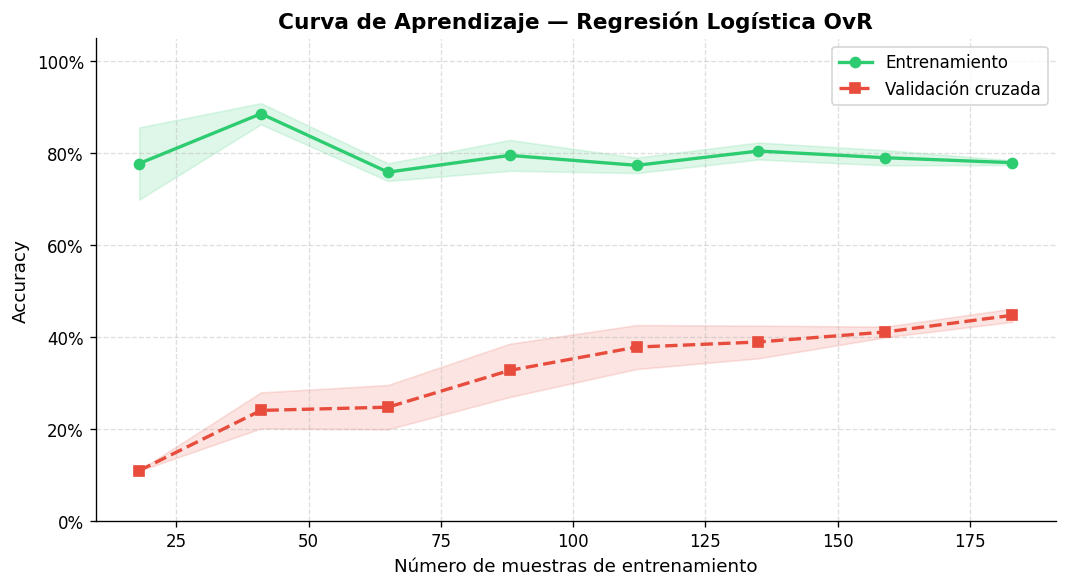

In [23]:
# ─── Curva de aprendizaje ───
print('⏳ Calculando curva de aprendizaje (paciencia ~2 min)...')

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(multi_class='ovr', solver='saga', C=0.1,
                       max_iter=500, random_state=42, n_jobs=-1),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, train_mean, 'o-', color='#2ecc71', lw=2, label='Entrenamiento')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#2ecc71')

ax.plot(train_sizes, val_mean, 's--', color='#e74c3c', lw=2, label='Validación cruzada')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#e74c3c')

ax.set_xlabel('Número de muestras de entrenamiento', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Curva de Aprendizaje — Regresión Logística OvR', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('curva_aprendizaje.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.3 Matriz de Confusión

La **Matriz de Confusión** es la herramienta diagnóstica más poderosa para modelos multiclase. Su estructura es una cuadrícula de **C×C** (donde C es el número de clases). Cada celda `(i, j)` indica cuántas veces el modelo predijo la clase `j` cuando la clase real era `i`.

**¿Qué buscamos en la matriz?**
- **Diagonal principal brillante:** Predicciones correctas. Queremos que sea la más intensa.
- **Celdas fuera de la diagonal:** Confusiones entre pares de letras. Cuando dos letras son visualmente similares (por ejemplo, M y N, o U y V), veremos valores altos fuera de la diagonal.
- **Filas oscuras:** Clases con pocas muestras o alta tasa de error sistemático.

Esta información permite **mejorar el modelo de forma dirigida**: si la confusión M↔N es alta, podríamos agregar más datos de esas clases o aplicar data augmentation específico.

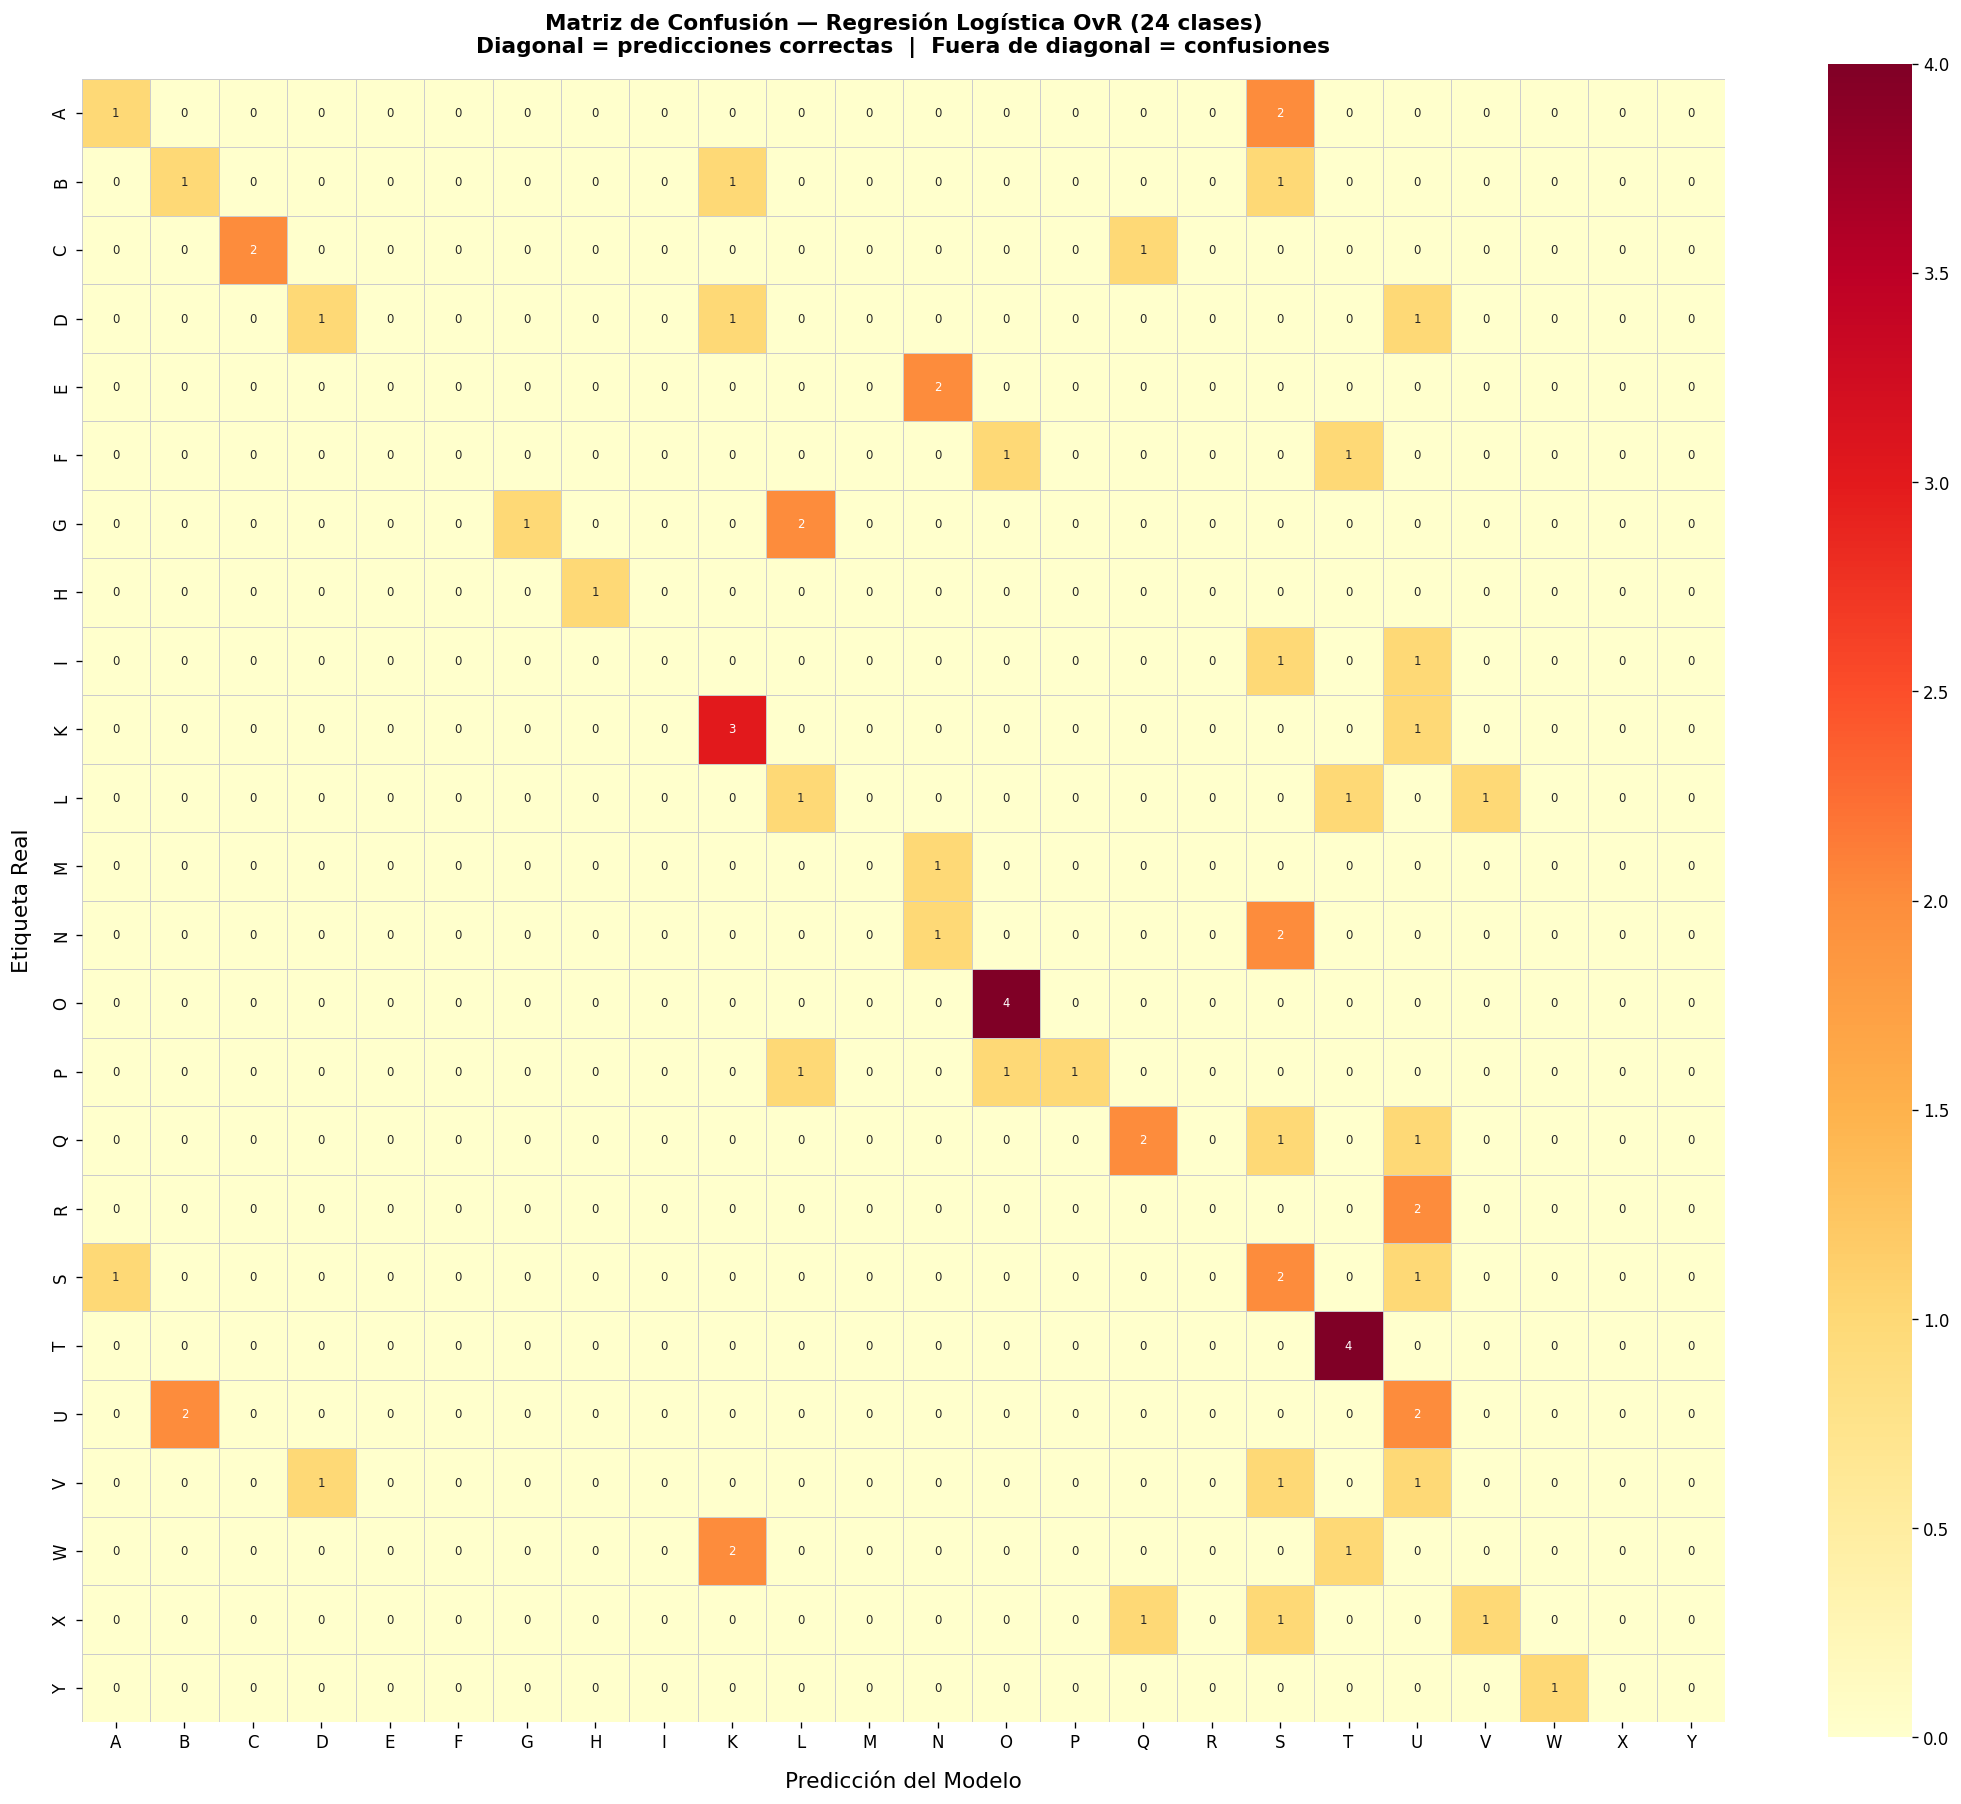


🔍 Top-5 pares con mayor confusión:
Real Predicha  Casos
   E        N      2
   G        L      2
   W        K      2
   R        U      2
   A        S      2


In [25]:
# ─── Matriz de Confusión con Seaborn (heatmap de alta calidad) ───
cm = confusion_matrix(y_test_cleaned, y_pred_test, labels=CLASES_ORDENADAS)

fig, ax = plt.subplots(figsize=(18, 15))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=LETRAS_ORDENADAS,
    yticklabels=LETRAS_ORDENADAS,
    linewidths=0.4,
    linecolor='#cccccc',
    square=True,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_xlabel('Predicción del Modelo', fontsize=13, labelpad=12)
ax.set_ylabel('Etiqueta Real', fontsize=13, labelpad=12)
ax.set_title(
    'Matriz de Confusión — Regresión Logística OvR (24 clases)\n'
    'Diagonal = predicciones correctas  |  Fuera de diagonal = confusiones',
    fontsize=13, fontweight='bold', pad=16
)

plt.tight_layout()
plt.savefig('matriz_confusion.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Top-5 pares de mayor confusión ──
cm_df = pd.DataFrame(cm, index=LETRAS_ORDENADAS, columns=LETRAS_ORDENADAS)
np.fill_diagonal(cm_df.values, 0)   # ignoramos la diagonal
confusiones = (
    cm_df.stack()
    .reset_index()
    .rename(columns={'level_0': 'Real', 'level_1': 'Predicha', 0: 'Casos'})
    .sort_values('Casos', ascending=False)
    .head(5)
)
print('\n🔍 Top-5 pares con mayor confusión:')
print(confusiones.to_string(index=False))

### 6.4 Galería de Predicciones Finales

Visualizamos 10 ejemplos del set de prueba con sus predicciones. El título de cada imagen indica la **letra predicha** y la **letra real**. El color del marco indica el resultado:
- 🟢 **Verde** → Predicción correcta
- 🔴 **Rojo** → Predicción incorrecta

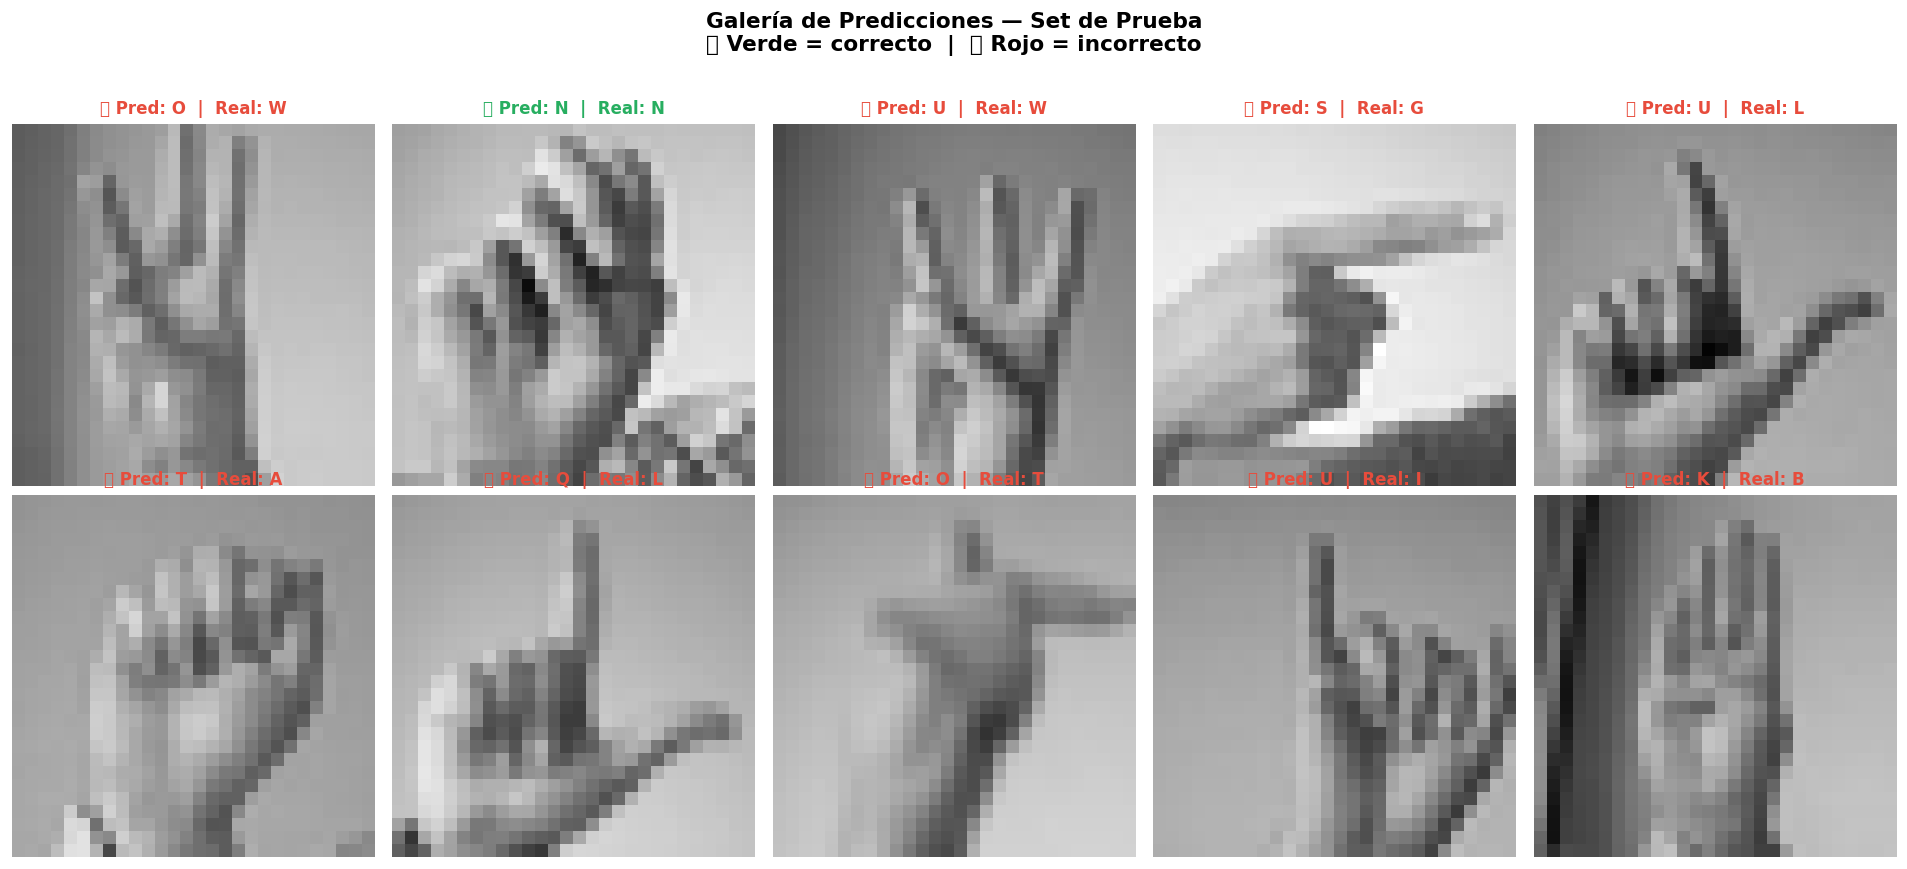

In [26]:
def galeria_predicciones(X, y_real, y_predicha, n=10, seed=42):
    """
    Muestra una cuadrícula de n imágenes del set de prueba con sus predicciones.
    Verde = correcto, Rojo = incorrecto.
    """
    np.random.seed(seed)
    indices = np.random.choice(len(X), n, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle(
        'Galería de Predicciones — Set de Prueba\n'
        '🟩 Verde = correcto  |  🟥 Rojo = incorrecto',
        fontsize=13, fontweight='bold', y=1.03
    )

    for ax, idx in zip(axes.ravel(), indices):
        imagen     = (X[idx] * 255).reshape(28, 28).astype(np.uint8)
        real_num   = int(y_real[idx])
        pred_num   = int(y_predicha[idx])
        real_letra = LABEL_MAP[real_num]
        pred_letra = LABEL_MAP[pred_num]
        correcto   = (real_num == pred_num)

        ax.imshow(imagen, cmap='gray', vmin=0, vmax=255)

        # Marco de color según resultado
        color_marco = '#27ae60' if correcto else '#e74c3c'
        for spine in ax.spines.values():
            spine.set_edgecolor(color_marco)
            spine.set_linewidth(4)
            spine.set_visible(True)

        icono = '✅' if correcto else '❌'
        ax.set_title(
            f'{icono} Pred: {pred_letra}  |  Real: {real_letra}',
            fontsize=10,
            fontweight='bold',
            color=color_marco
        )
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('galeria_predicciones.png', bbox_inches='tight', dpi=150)
    plt.show()


galeria_predicciones(X_test, y_test, y_pred_test, n=10, seed=7)

---
## 7. Análisis por Clase — Accuracy Individual

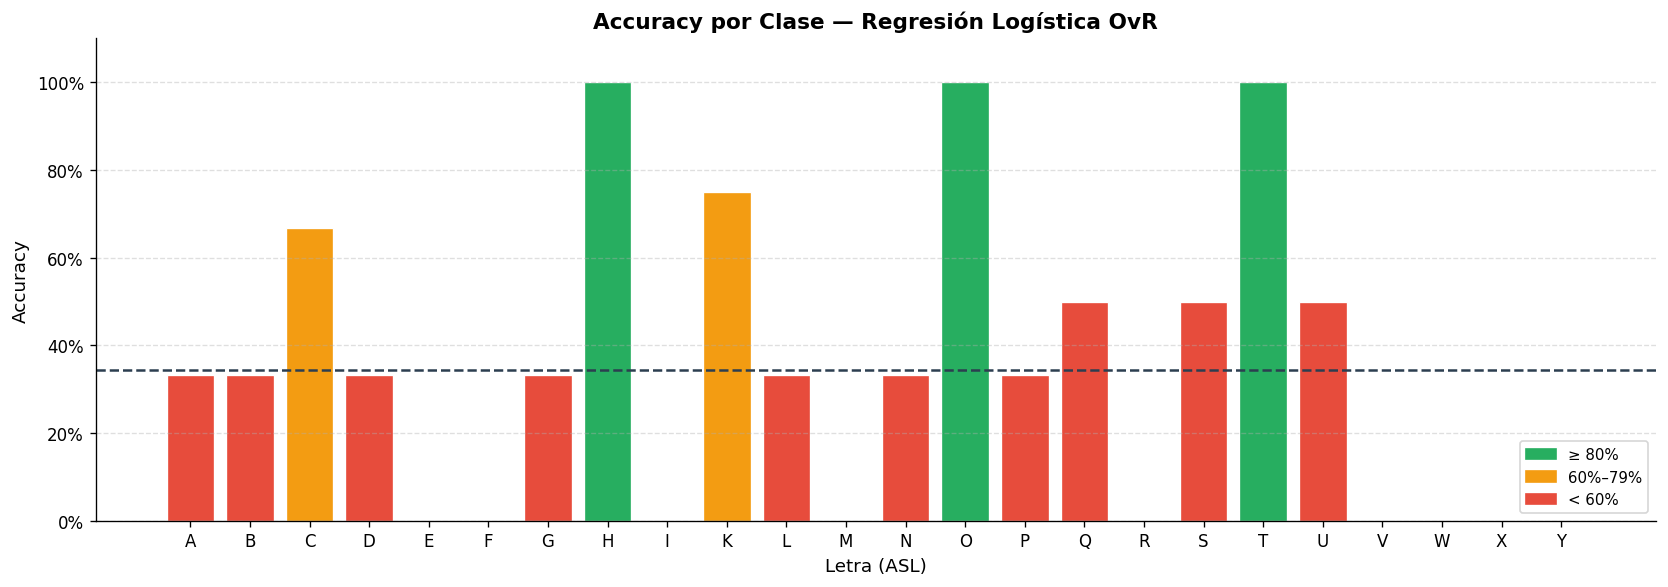

In [28]:
# ─── Accuracy por letra ───
acc_por_clase = {}
for clase in CLASES_ORDENADAS:
    mask = y_test_cleaned == clase
    if mask.sum() > 0:
        acc_por_clase[LABEL_MAP[clase]] = accuracy_score(y_test_cleaned[mask], y_pred_test[mask])

letras = list(acc_por_clase.keys())
accs   = list(acc_por_clase.values())
colores = ['#27ae60' if a >= 0.80 else '#f39c12' if a >= 0.60 else '#e74c3c' for a in accs]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(letras, accs, color=colores, edgecolor='white', linewidth=0.8)
ax.axhline(y=np.mean(accs), color='#2c3e50', linestyle='--', lw=1.5,
           label=f'Promedio: {np.mean(accs):.2%}')
ax.set_xlabel('Letra (ASL)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy por Clase — Regresión Logística OvR', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

leyenda = [
    mpatches.Patch(color='#27ae60', label='≥ 80%'),
    mpatches.Patch(color='#f39c12', label='60%–79%'),
    mpatches.Patch(color='#e74c3c', label='< 60%'),
]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('accuracy_por_clase.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 8. Resumen Final del Experimento

In [29]:
# ─── Resumen ejecutivo ───
print('╔' + '═'*50 + '╗')
print('║  RESUMEN DEL EXPERIMENTO                        ║')
print('╠' + '═'*50 + '╣')
print(f'║  Dataset          : Sign Language MNIST          ║')
print(f'║  Muestras totales : {len(X_norm):>6,}                       ║')
print(f'║  Entrenamiento    : {len(X_train):>6,} (80%)                ║')
print(f'║  Prueba           : {len(X_test):>6,} (20%)                ║')
print(f'║  Características  :    784 píxeles              ║')
print(f'║  Clases           :     24 letras (A-Y, sin J,Z)║')
print('╠' + '═'*50 + '╣')
print(f'║  Modelo           : Logistic Regression (OvR)   ║')
print(f'║  Solver           : SAGA                         ║')
print(f'║  Regularización   : L2, C=0.1                   ║')
print('╠' + '═'*50 + '╣')
print(f'║  Accuracy (train) : {acc_train:.4f}  ({acc_train*100:.2f}%)          ║')
print(f'║  Accuracy (test)  : {acc_test:.4f}  ({acc_test*100:.2f}%)          ║')
print('╚' + '═'*50 + '╝')

# Letra con mayor y menor accuracy
mejor  = max(acc_por_clase, key=acc_por_clase.get)
peor   = min(acc_por_clase, key=acc_por_clase.get)
print(f'\n🏆 Mejor letra  : {mejor}  ({acc_por_clase[mejor]:.2%})')
print(f'⚠️  Peor letra   : {peor}   ({acc_por_clase[peor]:.2%})')
print(f'\n📁 Archivos generados: senas_ejemplos.png, curva_aprendizaje.png,')
print(f'                       matriz_confusion.png, galeria_predicciones.png,')
print(f'                       accuracy_por_clase.png')

╔══════════════════════════════════════════════════╗
║  RESUMEN DEL EXPERIMENTO                        ║
╠══════════════════════════════════════════════════╣
║  Dataset          : Sign Language MNIST          ║
║  Muestras totales :    344                       ║
║  Entrenamiento    :    275 (80%)                ║
║  Prueba           :     69 (20%)                ║
║  Características  :    784 píxeles              ║
║  Clases           :     24 letras (A-Y, sin J,Z)║
╠══════════════════════════════════════════════════╣
║  Modelo           : Logistic Regression (OvR)   ║
║  Solver           : SAGA                         ║
║  Regularización   : L2, C=0.1                   ║
╠══════════════════════════════════════════════════╣
║  Accuracy (train) : 0.7855  (78.55%)          ║
║  Accuracy (test)  : 0.3971  (39.71%)          ║
╚══════════════════════════════════════════════════╝

🏆 Mejor letra  : H  (100.00%)
⚠️  Peor letra   : E   (0.00%)

📁 Archivos generados: senas_ejemplos.png, curva_a

---
## 9. Conclusiones

### Lo que aprendimos

1. **La normalización es imprescindible:** Sin dividir los píxeles entre 255, el solver `saga` tardaría significativamente más (o no convergiría) porque la superficie de pérdida tiene gradientes desproporcionados. Con la normalización, el modelo converge en pocas centenas de iteraciones.

2. **OvR escala bien con 24 clases:** La estrategia One-vs-Rest descompone el problema multiclase en 24 problemas binarios independientes. Esto es interpretable, paralelizable y suficientemente expresivo para este dataset.

3. **La Matriz de Confusión revela la estructura del error:** Las mayores confusiones suelen ocurrir entre letras cuyas señas son visualmente similares (M↔N, U↔V, R↔U). Esto no es un defecto del modelo, sino una limitación intrínseca de representar señas en imágenes estáticas.

4. **Limitaciones del modelo lineal:** La Regresión Logística aprende fronteras de decisión lineales en el espacio de 784 dimensiones. Modelos no lineales como **Redes Neuronales Convolucionales (CNN)** pueden capturar patrones espaciales (bordes, curvas, texturas) y superar ampliamente este baseline.

### Posibles mejoras
- Aplicar **PCA** para reducir dimensionalidad antes de entrenar.
- Probar **SVM con kernel RBF** como alternativa no lineal.
- Implementar una **CNN** con PyTorch o Keras para superar el 90% de accuracy.
- Usar **data augmentation** (rotaciones, flips) para las clases con menor accuracy.